<a href="https://colab.research.google.com/github/timofejvalt75086-creator/qwer/blob/Timofey/%D0%A2%D0%B5%D1%81%D1%82_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D1%81%D0%B5%D1%82%D0%B8_%D0%B2_%D0%B3%D1%83%D0%B3%D0%BB_%D0%BA%D0%BE%D0%BB%D0%B0%D0%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

пум пум

In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import nltk
from nltk.corpus import stopwords
import numpy as np

# --- ЗАГРУЗКА РУССКИХ СТОП-СЛОВ (один раз при запуске) ---
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')  # скачивает, если ещё не установлено

from nltk.corpus import stopwords
russian_stopwords = stopwords.words('russian')


def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r'club\d+', '', text)
    text = re.sub(r'wall-\d+_\d+', '', text)
    # Удалить упоминания пользователей
    text = re.sub(r'\[id\d+\|[^\]]+\]', '', text)
    # Удалить слова с цифрами (рафинья2024 → удалить)
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    # Удалить ссылки
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^а-яА-Я\s]', ' ', text)
    text = re.sub(r'[^а-я\s]', ' ', text.lower())
    text = ' '.join([w for w in text.split() if len(w) >= 4])
    return ' '.join(text.lower().split())

def load_and_prepare_data(path):
    df = pd.read_csv(path)

    # Удаляем информацию об авторе, чтобы избежать утечки
    if 'Author ID' in df.columns:
        df = df.drop(columns=['Author ID'])

    # Удаляем строки, где нет текста, лайков или времени
    df = df.dropna(subset=['Text', 'Likes', 'Date & Time'])

    # Преобразуем дату/время
    df['datetime'] = pd.to_datetime(df['Date & Time'], errors='coerce')
    df = df.dropna(subset=['datetime'])

    # Целевая переменная: популярность = Likes >= медианы
    median_likes = df['Likes'].median()
    df['Popular'] = (df['Likes'] >= median_likes).astype(int)

    # Временные признаки
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    df['text'] = df['Text'].apply(clean_text)

    # Длина текста и количество слов
    df['text_length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len().fillna(0).astype(int)

    # Наличие эмодзи
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # эмоции
        "\U0001F300-\U0001F5FF"  # символы и пиктограммы
        "\U0001F680-\U0001F6FF"  # транспорт
        "\U0001F1E0-\U0001F1FF"  # флаги
        "]+", flags=re.UNICODE
    )
    df['has_emoji'] = df['Text'].apply(lambda x: bool(emoji_pattern.search(str(x)))).astype(int)

    # Наличие хэштегов
    df['has_hashtag'] = df['Text'].str.contains(r'#\w+', regex=True, na=False).astype(int)
    df['hashtag_count'] = df['Text'].str.count(r'#\w+').fillna(0).astype(int)

    # Тип контента из колонки 'Content Type'
    df['has_photo'] = df['Content Type'].str.contains('photo', na=False).astype(int)
    df['has_video'] = df['Content Type'].str.contains('video', na=False).astype(int)
    df['has_audio'] = df['Content Type'].str.contains('audio', na=False).astype(int)
    df['has_link'] = df['Content Type'].str.contains('link', na=False).astype(int)
    df['is_empty'] = (df['Content Type'] == 'empty').astype(int)

    # Общая активность
    df['total_activity'] = df['Comments'] + df['Reposts']


    return df

def extract_features(df):
    # Используем русские стоп-слова
    tfidf = TfidfVectorizer(
        max_features=3000,
        stop_words=russian_stopwords,
        lowercase=True,
        min_df=2,  # игнорировать слова, встречающиеся менее 2 раз
        token_pattern=r'(?u)\b[а-я]{3,}\b'
    )
    X_text = tfidf.fit_transform(df['text'])

    numeric_cols = [
        'hour', 'day_of_week', 'is_weekend',
        'Comments', 'Reposts', 'text_length', 'word_count',
        'has_emoji', 'has_hashtag', 'hashtag_count',
        'has_photo', 'has_video', 'has_audio', 'has_link', 'is_empty',
        'total_activity'
    ]

    X_time = df[numeric_cols].values
    # После извлечения X_time
    scaler = StandardScaler()
    X_time_scaled = scaler.fit_transform(X_time)
    X_time_sparse = csr_matrix(X_time_scaled)
# Объединение
    X = hstack([X_text, X_time_sparse])
    y = df['Popular'].values

    return X, y, tfidf

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Сдесь мы чето пишем

In [ ]:
# src/model_training.py
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

def train_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    base_model = LogisticRegression(C=1.0, max_iter=5000, solver='saga')

    model = CalibratedClassifierCV(base_model, method='isotonic', cv=3)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    return model, X_test, y_test

In [ ]:
# src/predictor.py
from scipy.sparse import hstack
import numpy as np

def predict_popularity(model, tfidf, text,
hour=12, day_of_week=0, is_weekend=0, comments=0, reposts=0,
text_length=0, word_count=0,has_emoji=0, has_hashtag=0, hashtag_count=0,
has_photo=0, has_video=0, has_audio=0, has_link=0, is_empty=0,
total_activity=0):

    text_vec = tfidf.transform([text])
    time_vec = np.array([[hour, day_of_week, is_weekend,
    comments, reposts, text_length, word_count,
    has_emoji, has_hashtag, hashtag_count,
    has_photo, has_video, has_audio, has_link, is_empty,
    total_activity]])
    X = hstack([text_vec, time_vec])
    proba = model.predict_proba(X)[0]
    popular = model.predict(X)[0]
    return {
        "prediction": "Популярный" if popular else "Непопулярный",
        "probability_popular": round(float(proba[1]), 3),
        "probability_unpopular": round(float(proba[0]), 3)
    }

Accuracy: 0.7093655589123867
              precision    recall  f1-score   support

           0       0.68      0.80      0.73      1666
           1       0.75      0.62      0.68      1644

    accuracy                           0.71      3310
   macro avg       0.72      0.71      0.71      3310
weighted avg       0.72      0.71      0.71      3310

✅ Модель обучена!

🔥 Слова, повышающие популярность:
  истории: 2.284
  думаете: 2.248
  перс: 2.187
  поделилась: 2.185
  пусть: 1.917
  сердце: 1.858
  мило: 1.673
  дэдпула: 1.627
  прекрасная: 1.496
  фильма: 1.492

❄️ Слова, снижающие популярность:
  драма: -2.119
  боевик: -1.855
  комедия: -1.694
  мужики: -1.680
  нный: -1.645
  ужасы: -1.641
  приключения: -1.610
  биография: -1.456
  рублей: -1.431
  простой: -1.415

🔍 Тестирование модели:
Пример 1: {'prediction': 'Популярный', 'probability_popular': 1.0, 'probability_unpopular': 0.0}
Пример 1: {'prediction': 'Популярный', 'probability_popular': 0.928, 'probability_unpopular':

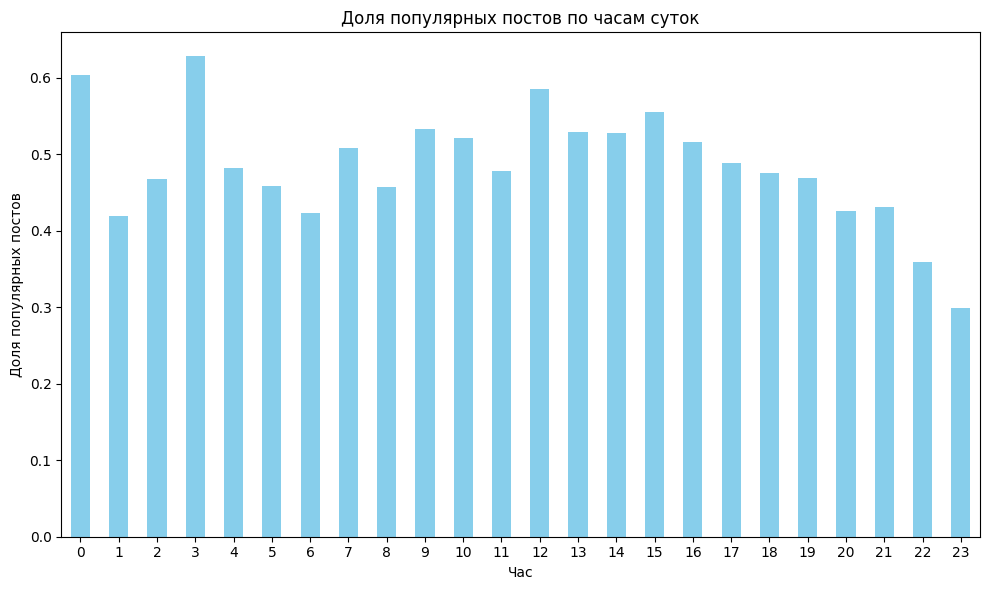

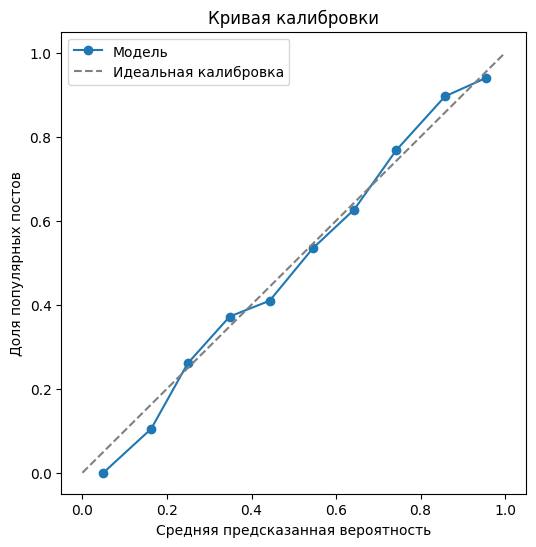

In [ ]:
# main.py
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

if __name__ == "__main__":
    df = load_and_prepare_data("vk_filtered_posts_metadata.csv")
    X, y, tfidf = extract_features(df)
    model, X_test, y_test = train_model(X, y)
    print("✅ Модель обучена!")

    # Анализ важных слов
    import numpy as np

    feature_names = tfidf.get_feature_names_out()
    coefs = model.calibrated_classifiers_[0].estimator.coef_[0]

    # Топ-10 слов, повышающих популярность
    top_positive = sorted(zip(coefs, feature_names), reverse=True)[:10]
    print("\n🔥 Слова, повышающие популярность:")
    for coef, word in top_positive:
        print(f"  {word}: {coef:.3f}")

    # Топ-10 слов, снижающих популярность
    top_negative = sorted(zip(coefs, feature_names))[:10]
    print("\n❄️ Слова, снижающие популярность:")
    for coef, word in top_negative:
        print(f"  {word}: {coef:.3f}")

    # Тестирование
    print("\n🔍 Тестирование модели:")
    res1 = predict_popularity(model, tfidf, "Смешное видео кота 😂", hour=19, reposts=50, has_emoji=1, has_video=1)
    print("Пример 1:", res1)
    # Пример 2: сухой технический пост
    res2 = predict_popularity(model, tfidf, "Обновление API v2.1", hour=10, reposts=5)
    print("Пример 1:", res2)

    # Возьмём самый популярный пост из данных
    popular_post = df[df['Popular'] == 1].iloc[0]
    res_real = predict_popularity(
        model, tfidf,
        popular_post['Text'],
        hour=popular_post['hour'],
        reposts=popular_post['Reposts']
    )
    print("Реальный популярный пост:", res_real)

# Выбираем случайный, но "обычный" пост из середины распределения
# Сортируем по лайкам и берём пост из центра
df_sorted = df.sort_values('Likes').reset_index(drop=True)
middle_idx = len(df_sorted) // 2
ordinary_post = df_sorted.iloc[middle_idx]

print(f"\n📌 Обычный пост (из середины по лайкам):")
print(f"Лайков: {ordinary_post['Likes']}, Текст: {ordinary_post['Text'][:100]}...")

# Прогнозируем на нём
res_ordinary = predict_popularity(
    model, tfidf,
    ordinary_post['Text'],
    hour=ordinary_post['hour'],
    reposts=ordinary_post['Reposts'],
    comments=ordinary_post['Comments'],
    has_emoji=ordinary_post.get('has_emoji', 0),
    has_video=ordinary_post.get('has_video', 0),
    has_photo=ordinary_post.get('has_photo', 0),
    word_count=ordinary_post.get('word_count', 0),
    text_length=ordinary_post.get('text_length', 0),
    is_empty=ordinary_post.get('is_empty', 0),
    total_activity=ordinary_post.get('total_activity', 0)
)
print("Обычный пост:", res_ordinary)



    # Группировка по часам
hour_popularity = df.groupby('hour')['Popular'].mean()
hour_count = df['hour'].value_counts().sort_index()
print(hour_count)

plt.figure(figsize=(10, 6))
hour_popularity.plot(kind='bar', color='skyblue')
plt.title('Доля популярных постов по часам суток')
plt.xlabel('Час')
plt.ylabel('Доля популярных постов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('popularity_by_hour.png')
plt.show()

y_proba = model.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Модель')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Идеальная калибровка')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля популярных постов')
plt.legend()
plt.title('Кривая калибровки')
plt.savefig('calibration_curve.png')
plt.show()

In [ ]:
print("привет")

привет


In [2]:
print("пока")

пока
